# Sales Prediction using Python

## Introduction

Sales prediction is the process of estimating future sales based on historical data and relevant factors.

In this project, advertising expenditure is analyzed to understand its relationship with sales. Machine learning techniques are then used to build a regression model capable of predicting sales based on advertising spending.

### Objectives

- Analyze the relationship between advertising expenditure and sales.
- Clean and explore the dataset.
- Identify important factors affecting sales.
- Build a machine learning regression model.
- Evaluate the model's prediction performance.
- Generate insights that can support marketing decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\Advertising.csv")

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.shape

(200, 5)

In [6]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB

Statistical Summary:


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
df = df.drop(columns=["Unnamed: 0"])

# Check the updated dataset
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Dataset Shape: (200, 4)

Columns:
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Data Cleaning

The dataset contains an unnecessary `Unnamed: 0` column, which represents the original row index rather than a meaningful feature.

This column will be removed before performing exploratory data analysis and building the machine learning model.

The remaining variables are:

* **TV** – Advertising expenditure on TV
* **Radio** – Advertising expenditure on Radio
* **Newspaper** – Advertising expenditure on Newspaper
* **Sales** – Product sales and the target variable

The cleaned dataset will therefore contain four relevant columns.


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, and relationships within the dataset before building a machine learning model.

In this analysis, we will examine the descriptive statistics, distributions of the variables, relationships between advertising expenditure and Sales, and correlations among the numerical variables.


### Descriptive Statistics

Descriptive statistics are used to summarize the numerical characteristics of the dataset, including the mean, standard deviation, minimum, maximum, and quartile values.

This provides an initial understanding of the scale and variation of advertising expenditure and Sales.


In [11]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### Interpretation

The dataset contains **200 observations** with no missing values in any of the numerical variables.

* The average TV advertising expenditure is **147.04**, while Radio and Newspaper advertising expenditures have average values of **23.26** and **30.55**, respectively.
* The average Sales value is **14.02**.
* TV has the largest variation among the advertising channels, with values ranging from **0.70 to 296.40**.
* Radio advertising ranges from **0 to 49.60**, while Newspaper advertising ranges from **0.30 to 114.00**.
* Sales ranges from **1.60 to 27.00**.
* The difference between the mean and median values provides an initial indication that some variables may have skewed distributions, which will be examined through visualization.


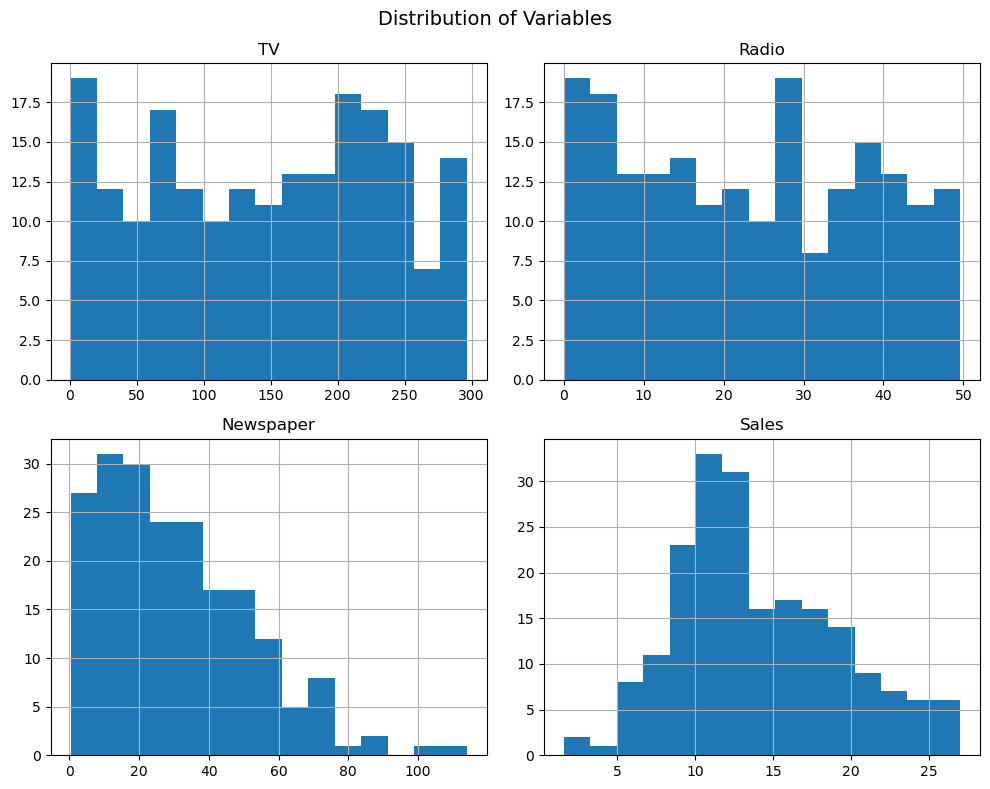

In [12]:
# Plot distributions of numerical variables

import matplotlib.pyplot as plt

df.hist(figsize=(10, 8), bins=15)

plt.suptitle("Distribution of Variables", fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation

The histograms provide an overview of the distributions of the advertising variables and Sales.

- **TV advertising** is spread across a wide range of values, with observations distributed throughout the range.
- **Radio advertising** is also broadly distributed, with values ranging from low to high advertising expenditure.
- **Newspaper advertising** is **right-skewed**, with most observations concentrated at lower expenditure levels and fewer observations at higher values.
- **Sales** is mainly concentrated around the middle range, with fewer observations at very low and very high sales values.
- The distributions do not show any obvious extreme abnormalities that would prevent further analysis.

Overall, the distributions provide a useful understanding of the data before examining the relationships between advertising expenditure and Sales.

### Relationship Between Advertising Expenditure and Sales

Scatter plots are used to examine the relationship between each advertising channel and Sales.

The analysis will compare:

- TV advertising expenditure with Sales
- Radio advertising expenditure with Sales
- Newspaper advertising expenditure with Sales

A clear upward pattern would indicate a positive relationship between advertising expenditure and Sales.

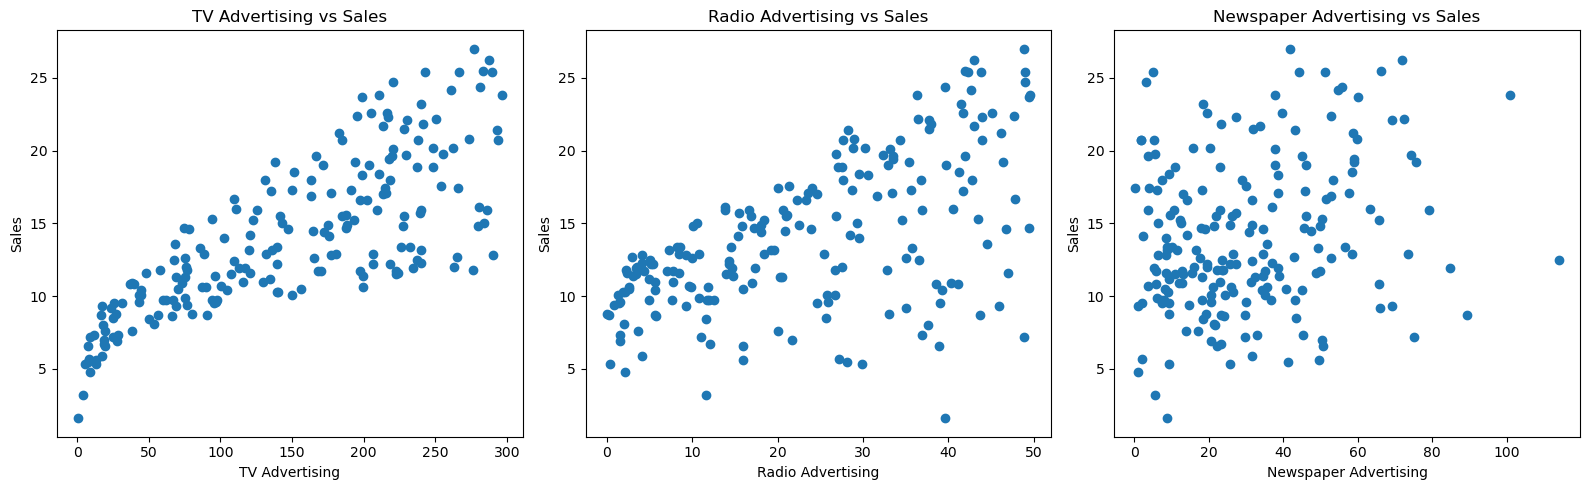

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# TV vs Sales
axes[0].scatter(df["TV"], df["Sales"])
axes[0].set_title("TV Advertising vs Sales")
axes[0].set_xlabel("TV Advertising")
axes[0].set_ylabel("Sales")

# Radio vs Sales
axes[1].scatter(df["Radio"], df["Sales"])
axes[1].set_title("Radio Advertising vs Sales")
axes[1].set_xlabel("Radio Advertising")
axes[1].set_ylabel("Sales")

# Newspaper vs Sales
axes[2].scatter(df["Newspaper"], df["Sales"])
axes[2].set_title("Newspaper Advertising vs Sales")
axes[2].set_xlabel("Newspaper Advertising")
axes[2].set_ylabel("Sales")

plt.tight_layout()
plt.show()

### Interpretation

The scatter plots show the relationship between each advertising channel and Sales.

- **TV Advertising vs Sales:** A clear positive relationship can be observed. Sales generally increase as TV advertising expenditure increases. The points follow a fairly strong upward pattern.
- **Radio Advertising vs Sales:** A positive relationship is also visible. Higher Radio advertising expenditure is generally associated with higher Sales, although the observations show more variation than TV.
- **Newspaper Advertising vs Sales:** The relationship appears weaker compared with TV and Radio. The points are more widely scattered, indicating that Newspaper advertising has a less pronounced linear relationship with Sales.
- Overall, **TV and Radio advertising appear to have stronger relationships with Sales than Newspaper advertising**.

These observations will be further verified using correlation analysis.

### Correlation Analysis

Correlation analysis is used to measure the strength and direction of the linear relationship between the numerical variables.

The correlation coefficient ranges from **-1 to +1**:

- A value close to **+1** indicates a strong positive relationship.
- A value close to **0** indicates a weak or no linear relationship.
- A value close to **-1** indicates a strong negative relationship.

The correlation between TV, Radio, Newspaper, and Sales will be examined to identify the advertising variables most strongly associated with Sales.

In [14]:
correlation_matrix = df.corr()

print(correlation_matrix)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


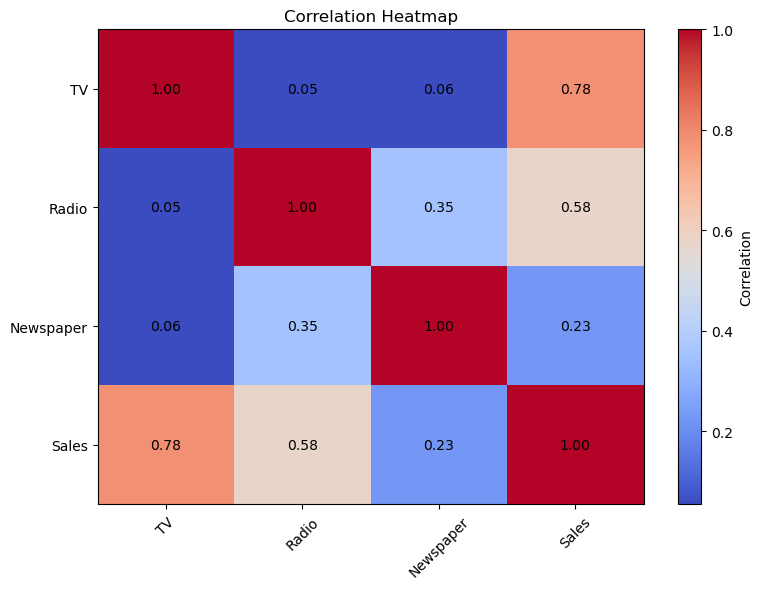

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Interpretation

The correlation analysis shows the strength and direction of the relationships between advertising expenditure and Sales.

- **TV and Sales:** The correlation is **0.782**, indicating a strong positive relationship. Among the three advertising channels, TV has the strongest correlation with Sales.
- **Radio and Sales:** The correlation is **0.576**, indicating a moderate positive relationship between Radio advertising and Sales.
- **Newspaper and Sales:** The correlation is **0.228**, indicating a relatively weak positive relationship with Sales.
- The correlations between the advertising channels themselves are relatively low, except for Radio and Newspaper (**0.354**), suggesting limited linear relationship between most predictors.

Overall, **TV advertising has the strongest linear relationship with Sales, followed by Radio and Newspaper**. These variables can therefore be considered as potential predictors for the machine learning model.

### EDA Summary

The exploratory data analysis provided the following key observations:

1. The dataset contains **200 observations** and four relevant numerical variables: TV, Radio, Newspaper, and Sales.
2. There are no missing values or duplicate observations.
3. TV advertising expenditure shows the strongest positive relationship with Sales.
4. Radio advertising also has a moderate positive relationship with Sales.
5. Newspaper advertising has a weaker relationship with Sales compared with TV and Radio.
6. The scatter plots and correlation analysis provide consistent evidence that higher TV and Radio advertising expenditure is generally associated with higher Sales.

These findings indicate that TV, Radio, and Newspaper can be used as predictor variables for developing a Sales prediction model.

## Feature Selection

Based on the exploratory data analysis, TV, Radio, and Newspaper advertising expenditure will be used as predictor variables.

The target variable for the prediction task is Sales.

Therefore:

- **Features (X):** TV, Radio, Newspaper
- **Target (y):** Sales

The objective is to build a regression model that can predict Sales based on advertising expenditure.

In [16]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Features shape: (200, 3)
Target shape: (200,)

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


## Train-Test Split

The dataset is divided into training and testing sets before building the machine learning model.

The **training set** is used to train the regression model, while the **testing set** is used to evaluate how well the model performs on unseen data.

An 80:20 split will be used:

- **80% of the data** → Training set
- **20% of the data** → Testing set

Since the dataset contains 200 observations, this results in approximately 160 training observations and 40 testing observations.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


## Linear Regression Model

Multiple Linear Regression is used to predict Sales based on TV, Radio, and Newspaper advertising expenditure.

The model learns the relationship between the three predictor variables and the target variable, Sales.

The general form of the model is:

**Sales = β₀ + β₁(TV) + β₂(Radio) + β₃(Newspaper)**

where:

- **β₀** is the intercept.
- **β₁** represents the effect of TV advertising on Sales.
- **β₂** represents the effect of Radio advertising on Sales.
- **β₃** represents the effect of Newspaper advertising on Sales.

The model will be trained using the 160 observations in the training dataset.

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Model Coefficients

The regression coefficients indicate how the predicted Sales changes with each advertising variable while keeping the other variables constant.

A positive coefficient indicates that an increase in the corresponding advertising expenditure is associated with an increase in predicted Sales.

The intercept represents the predicted Sales when all advertising expenditures are zero.

In [19]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: 2.979067338122629

Coefficients:
TV: 0.0447
Radio: 0.1892
Newspaper: 0.0028


### Interpretation of Model Coefficients

The trained Linear Regression model produced the following coefficients:

- **Intercept = 2.9791:** When TV, Radio, and Newspaper advertising expenditure are zero, the model predicts Sales of approximately 2.98 units.
- **TV coefficient = 0.0447:** For a one-unit increase in TV advertising expenditure, predicted Sales increase by approximately 0.0447 units, assuming Radio and Newspaper expenditure remain constant.
- **Radio coefficient = 0.1892:** For a one-unit increase in Radio advertising expenditure, predicted Sales increase by approximately 0.1892 units, assuming the other advertising expenditures remain constant.
- **Newspaper coefficient = 0.0028:** For a one-unit increase in Newspaper advertising expenditure, predicted Sales increase by approximately 0.0028 units, assuming the other variables remain constant.

All three coefficients are positive, indicating a positive association between advertising expenditure and predicted Sales.

The coefficients should be interpreted while keeping the other predictor variables constant. The magnitude of a coefficient alone should not be used to directly compare the importance of variables because the predictors are measured on different scales.

## Sales Prediction

The trained Linear Regression model is now used to predict Sales for the testing dataset.

The testing data was not used during model training, allowing us to evaluate how well the model performs on previously unseen observations.

The predicted Sales values will be compared with the actual Sales values to assess the model's performance.

In [20]:

y_pred = model.predict(X_test)

print("Number of predictions:", len(y_pred))
print("\nFirst 10 predicted Sales values:")
print(y_pred[:10])

Number of predictions: 40

First 10 predicted Sales values:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [21]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


## Model Evaluation

The performance of the Linear Regression model is evaluated using the testing dataset.

The following regression metrics are used:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted Sales values. Lower values indicate better performance.
- **Mean Squared Error (MSE):** Measures the average squared difference between actual and predicted values. Lower values indicate fewer prediction errors.
- **Root Mean Squared Error (RMSE):** The square root of MSE. It is expressed in the same units as Sales, making it easier to interpret.
- **R² Score:** Measures the proportion of variation in Sales explained by the model. A value closer to 1 indicates better explanatory performance.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Evaluation Results
------------------------
MAE  : 1.4608
MSE  : 3.1741
RMSE : 1.7816
R²   : 0.8994


### Interpretation of Model Evaluation

The Linear Regression model achieved the following results:

- **MAE = 1.4608:** On average, the predicted Sales values differ from the actual values by approximately **1.46 units**.
- **MSE = 3.1741:** The average squared prediction error is approximately **3.17**.
- **RMSE = 1.7816:** The typical prediction error is approximately **1.78 Sales units**.
- **R² = 0.8994:** The model explains approximately **89.94% of the variation in Sales** based on TV, Radio, and Newspaper advertising expenditure.

Overall, the model demonstrates strong predictive performance. The high R² value indicates that the selected advertising variables explain most of the variation in Sales, while the relatively low MAE and RMSE indicate that the predictions are reasonably close to the actual Sales values.

## Actual vs Predicted Sales

A scatter plot of actual versus predicted Sales is used to visually evaluate the performance of the regression model.

If the predictions are accurate, the points should be close to the diagonal reference line.

The diagonal line represents a situation where:

**Actual Sales = Predicted Sales**

Therefore, points closer to this line indicate more accurate predictions.

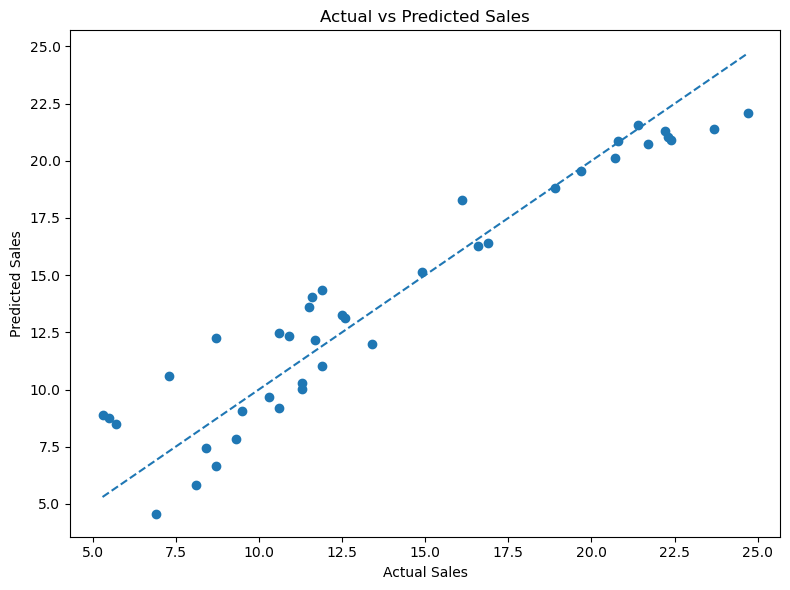

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Reference line: Actual = Predicted
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()
plt.show()

### Interpretation

The Actual vs Predicted Sales plot shows that most predicted values are reasonably close to the diagonal reference line.

- The diagonal line represents perfect predictions where Actual Sales equals Predicted Sales.
- Most observations follow the diagonal line, indicating that the model provides reasonably accurate predictions.
- Some observations show larger differences between actual and predicted Sales, particularly at certain lower and higher Sales values.
- Overall, the plot supports the model's strong performance, which is consistent with the **R² score of 0.8994**.

The model therefore demonstrates a good ability to predict Sales from advertising expenditure.

## Residual Analysis

Residuals represent the difference between the actual and predicted Sales values.

The residual is calculated as:

**Residual = Actual Sales − Predicted Sales**

Residual analysis helps determine whether the regression model has captured the underlying relationship adequately.

Ideally, residuals should be randomly scattered around zero without a clear pattern.

In [24]:
residuals = y_test - y_pred

print("First 10 residuals:")
print(residuals.head(10))

First 10 residuals:
95     0.491976
15     1.510118
30    -0.153843
158   -3.308503
128    2.587627
115   -0.505592
69     1.242808
170    0.938990
174   -2.106346
45    -0.255070
Name: Sales, dtype: float64


### Interpretation of Residuals

The residuals represent the difference between actual and predicted Sales.

The results contain both positive and negative residuals:

- A **positive residual** means the model predicted a lower Sales value than the actual value.
- A **negative residual** means the model predicted a higher Sales value than the actual value.
- Most residuals are relatively small, although a few observations have larger errors.

For example, a residual of approximately **-3.31** indicates that the model overpredicted the corresponding Sales value by about 3.31 units.

The residuals will be visualized against the predicted Sales values to check whether the errors are randomly distributed around zero.

### Residuals vs Predicted Sales

A residual plot is used to check whether the prediction errors are randomly distributed around zero.

For a well-behaved linear regression model, residuals should generally be scattered around the zero line without a clear systematic pattern.

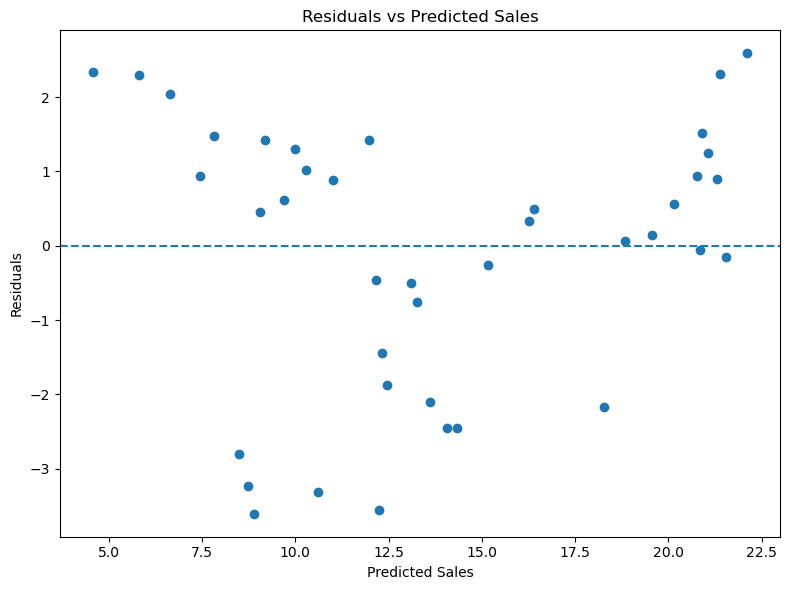

In [25]:


plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)


plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Sales")

plt.tight_layout()
plt.show()

### Interpretation of Residual Plot

The residual plot shows that the residuals are distributed both above and below the zero line. However, a noticeable curved pattern can be observed, with residuals tending to be positive at lower and higher predicted Sales values and more negative around the middle range.

This indicates that the Linear Regression model may not capture all of the underlying non-linear relationships in the data.

Despite this pattern, the model achieved a strong **R² score of 0.8994**, indicating that it explains approximately 89.94% of the variation in Sales.

Therefore, the Linear Regression model provides good predictive performance, while the residual analysis suggests that more advanced or non-linear models could potentially improve the predictions further.

## Final Findings

This project analyzed the relationship between advertising expenditure and Sales and developed a Linear Regression model to predict Sales.

### Key Findings

- The dataset contains **200 observations** and three relevant advertising features: TV, Radio, and Newspaper.
- No missing values or duplicate observations were identified.
- **TV advertising** showed the strongest correlation with Sales (**0.782**).
- **Radio advertising** showed a moderate positive correlation with Sales (**0.576**).
- **Newspaper advertising** showed a weaker positive correlation with Sales (**0.228**).
- A Multiple Linear Regression model was trained using TV, Radio, and Newspaper advertising expenditure.
- The model achieved an **MAE of 1.4608** and an **RMSE of 1.7816**.
- The model achieved an **R² score of 0.8994**, meaning approximately **89.94% of the variation in Sales is explained by the model**.
- The Actual vs Predicted plot showed that most predictions were reasonably close to the actual Sales values.
- Residual analysis indicated some non-linear patterns, suggesting that a more advanced model could potentially improve prediction performance.

### Conclusion

Overall, the Linear Regression model provides a strong baseline for predicting Sales from advertising expenditure. The analysis demonstrates that advertising investment, particularly TV and Radio advertising, has a meaningful relationship with Sales. The model can therefore be used as a starting point for estimating Sales based on advertising expenditure.

In [26]:
df.to_csv("advertising_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
